# <u>Multiple Linear Regression</u>

## Topics

* [1. Problem setup](#setup)
* [2. Assumptions for Simple Linea Regression](#assume)
* [3. Core Minimization problem (OLS)](#min)
* [4. Model Quality](#quality)
* [5. Statistical Inference](#stats)
* [6. (Batch) Gradient Descent](#gd)
* [7. Stochastic Gradient Descent (SGD)](#sgd)
* [8. Limitations](#limits)
    



In [82]:
import numpy as np # for random numbers and matrix calculus
import matplotlib.pyplot as plt # for plotting
import pandas as pd # for creating dataframes
import scipy.stats as stats # for Q-Q Plot
import statsmodels.api as sm # # for Statistical Inference
from scipy.stats import t,f # for Students t and F distribtuion
from scipy.stats import multivariate_normal # multivariate normal distribution
import plotly.graph_objects as go # interactive 3D plots but more complex
import plotly.express as px # also for interactive 3D plots but more simple
import seaborn as sns # for plotting
from statsmodels.stats.outliers_influence import variance_inflation_factor # for VIF factor

<a class="anchor" id="setup"></a>
## 1. Problem setup

In this notebook, I will introduce **Multiple Linear Regression**, a method used to predict a target (dependent variable) based on <u>multiple</u> features (independent variables).

The goal is to learn the relationship between the **features (predictors)** and the **target variable** using a linear model.

---

### Variables

* **$y$**: target vector of length $n$
* **$x_1$**: 1st feature vector of length $n$
* **$x_2$**: 2nd feature vector of length $n$
* $\vdots$
* **$x_p$**: $p$-th feature vector of length $n$

---

### Model (scalar form)

For each observation $i = 1, \dots, n$:

$$
y^{(i)} = \theta^\top x^{(i)} + \varepsilon^{(i)} 
= \theta_0 + \theta_1 x_1^{(i)} + \ldots + \theta_p x_p^{(i)} + \varepsilon^{(i)}
$$

where:

- $\theta = (\theta_0, \theta_1, \ldots, \theta_p) \in \mathbb{R}^{p+1}$ is the parameter vector  
- $x^{(i)} = (1, x_1^{(i)}, \ldots, x_p^{(i)}) \in \mathbb{R}^{p+1}$ is the feature vector (including intercept)  
- $\varepsilon^{(i)}$ is the error term capturing noise or unobserved factors  

---

### Prediction Model

The estimated model is:

$$
\hat{y}^{(i)} = \hat{\theta}^\top x^{(i)} 
= \hat{\theta}_0 + \hat{\theta}_1 x_1^{(i)} + \ldots + \hat{\theta}_p x_p^{(i)}
$$

where:

- $\hat{\theta}=(\hat{\theta}_0, \hat{\theta}_1, \ldots, \hat{\theta}_p) \in \mathbb{R}^{p+1}$ are the estimated parameters  
- $\hat{\theta}_j$ represents the effect of feature $x_j$ on the target $j=1,...,p$  
- $\hat{\theta}_0$ is the intercept (baseline prediction when all features are zero)  

---

### Matrix Formulation

We can express the model compactly using matrix notation:

$$
y = X\theta + \varepsilon
$$

where:

$$
y =
\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)}
\end{pmatrix}, 
\quad
X =
\begin{pmatrix}
1 & x_1^{(1)} & \ldots & x_p^{(1)} \\
1 & x_1^{(2)} & \ldots & x_p^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_1^{(n)} & \ldots & x_p^{(n)}
\end{pmatrix},
\quad
\theta =
\begin{pmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_p
\end{pmatrix}
$$

---

### Predictions in Matrix Form

$$
\hat{y} = X\hat{\theta}
$$

where:

$$
\hat{y} =
\begin{pmatrix}
\hat{y}^{(1)} \\
\hat{y}^{(2)} \\
\vdots \\
\hat{y}^{(n)}
\end{pmatrix}
$$

---

### &#128161; Interpretation

- Each row of $X$ represents one observation  
- Each column (except the first) represents a feature  
- The first column of ones accounts for the intercept  
- The model is **linear in the parameters** (even if features are transformed)



<a class="anchor" id="assume"></a>
## 2. Assumptions for Multiple Linear Regression

| Assumption | Description | Consequence | Verification |
|-----------|------------|-------------|--------------|
| **Linearity** | The relationship between the predictors and the target is linear in the parameters: $y = X\theta + \varepsilon$. |  Ensures unbiased and consistent estimates of $\hat{\theta}$ | Residuals vs. Fitted Plot, Partial regression plots |
| **Independent Errors** | Error terms are independent: $\varepsilon^{(i)}$ independent of $\varepsilon^{(j)}$ for $i \neq j$. |  Valid statistical inference (standard errors, hypothesis tests) | Residuals vs. Order Plot, Durbin–Watson test |
| **Homoscedasticity** | Constant variance of errors: $\mathrm{Var}(\varepsilon^{(i)}) = \sigma^2$ for all $i$; $\mathrm{Cov}(\varepsilon)=\sigma^2 I_n$ ,  $\sigma^2 \ge 0$ |  Correct standard errors and confidence intervals | Residuals vs. Fitted Plot |
| **Zero Mean Errors** | Errors are centered at zero: $\mathrm{E}[\varepsilon^{(i)}] = 0$. |  Ensures unbiasedness of $\hat{\theta}$ | Check mean of residuals (should be $\approx 0$) |
| **Normality of Errors  $\varepsilon^{(i)} \sim \mathcal{N}(0,\sigma^2)$** | Errors follow a normal distribution |  Enables exact inference (t-tests, F-tests, confidence intervals) | Q–Q plot of residuals, Histogram of residuals |
| **No Extreme Outliers / Influential Points** | No single observation should dominate the model fit. |  Stability of estimates and inference | Leverage plots, Cook’s distance, Residuals vs. Fitted |
| **Full Rank of $X$ (No Multicollinearity)** | The regression matrix $X$ has full column rank: $\text{rank}(X) = p+1 < n$. |  Unique solution $\hat{\theta} = (X^\top X)^{-1}X^\top y$ exists | Correlation matrix, Variance Inflation Factor (VIF) |


### Linearity

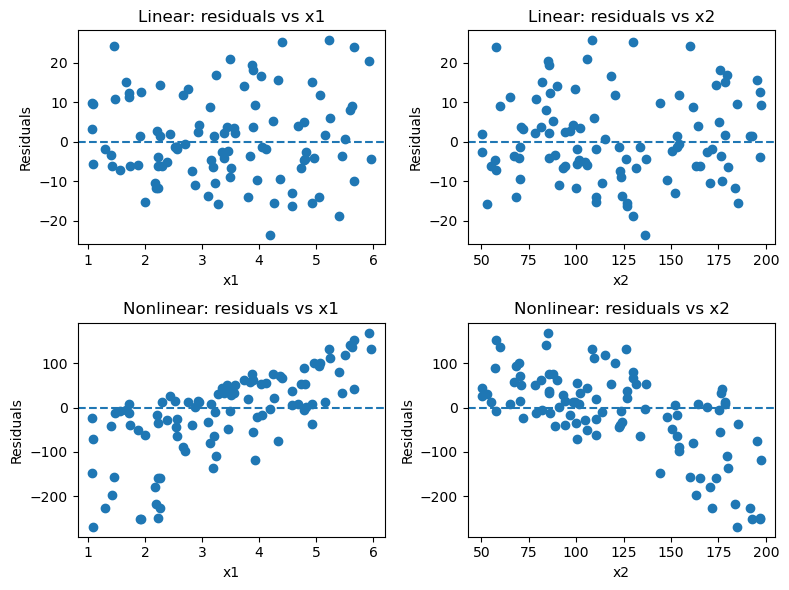

In [83]:
np.random.seed(1742) # for reproducibility of random numbers

n = 100 # number of observation/sample size

# Features
x_1 = np.random.uniform(1, 6, n) # e.g. number of rooms
x_2 = np.random.uniform(50, 200, n) # e.g. house size

X = np.column_stack([np.ones(n), x_1, x_2]) # regresion matrix

theta = np.array([5, 10, 0.5]) # parameter vector


# Linear data
true_y = X @ theta
error = np.random.normal(0, 10, n)
y = true_y + error

res = y - (X @ theta) # residuals


# Nonlinear data
true_y_nl = (
    5
    + 10 * x_1
    + 0.5 * x_2
    + 2 * (x_1**2) # curvature
    - 0.01 * (x_2**2) # curvature
    + 0.3 * (x_1 * x_2) # interaction
)

y_nl = true_y_nl + error

# linear model applied to nonlinear data to to show that a linear model is inappropriate
y_hat_linear = X @ theta
res_nl = y_nl - y_hat_linear


# 3D Plot Linear data
fig1 = px.scatter_3d(
    x=x_1, y=x_2, z=y,
    title="Linear Data",
    labels={'x':'x1', 'y':'x2', 'z':'y'}
)

# Create grid
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x_1.min(), x_1.max(), 20),
    np.linspace(x_2.min(), x_2.max(), 20)
)

grid_y = 5 + 10*grid_x1 + 0.5*grid_x2  # true linear model
grid_nonlinear= 5 + 10 * grid_x1 + 0.5 * grid_x2 + 2 * (grid_x1**2) - 0.01 * (grid_x2**2) + 0.3 * (grid_x1 * grid_x2)

# Add Regression plane
fig1.add_traces(
    go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=grid_y,
        opacity=0.4, # color intensity of plane
        showscale=False, # hides scalebar
        name="True Plane",
        showlegend=True # force to show legend
    )
)

fig1.update_layout(width=700, height=500)
fig1.show()


# 3D Plot Nonlinear data
fig2 = px.scatter_3d(
    x=x_1, y=x_2, z=y_nl,
    title="Nonlinear Data",
    labels={'x':'x1', 'y':'x2', 'z':'y'}
)

# Non linear plane
fig2.add_traces(
    go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=grid_nonlinear,
        opacity=0.4, # color intensity of plane
        showscale=False, # hides scalebar
        name="True Nonlinear Plane",
        showlegend=True  # force to show legend
    )
)

# Same linear plane (wrong model)
fig2.add_traces(
    go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=grid_y,
        opacity=0.4, # color intensity of plane
        showscale=False, # hides scalebar
        name="Linear Fit (Wrong Model)",
        showlegend=True # force to show legend 
    )
)


fig2.update_layout(width=700, height=500)
fig2.show()


# Residuals Plot
fig, axes = plt.subplots(2, 2, figsize=(8,6))

# Linear case
axes[0,0].scatter(x_1, res)
axes[0,0].axhline(0, linestyle="--")
axes[0,0].set_title("Linear: residuals vs x1")
axes[0,0].set_xlabel("x1")
axes[0,0].set_ylabel("Residuals")

axes[0,1].scatter(x_2, res)
axes[0,1].axhline(0, linestyle="--")
axes[0,1].set_title("Linear: residuals vs x2")
axes[0,1].set_xlabel("x2")
axes[0,1].set_ylabel("Residuals")

# Nonlinear case
axes[1,0].scatter(x_1, res_nl)
axes[1,0].axhline(0, linestyle="--")
axes[1,0].set_title("Nonlinear: residuals vs x1")
axes[1,0].set_xlabel("x1")
axes[1,0].set_ylabel("Residuals")

axes[1,1].scatter(x_2, res_nl)
axes[1,1].axhline(0, linestyle="--")
axes[1,1].set_title("Nonlinear: residuals vs x2")
axes[1,1].set_xlabel("x2")
axes[1,1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

### Independent errors

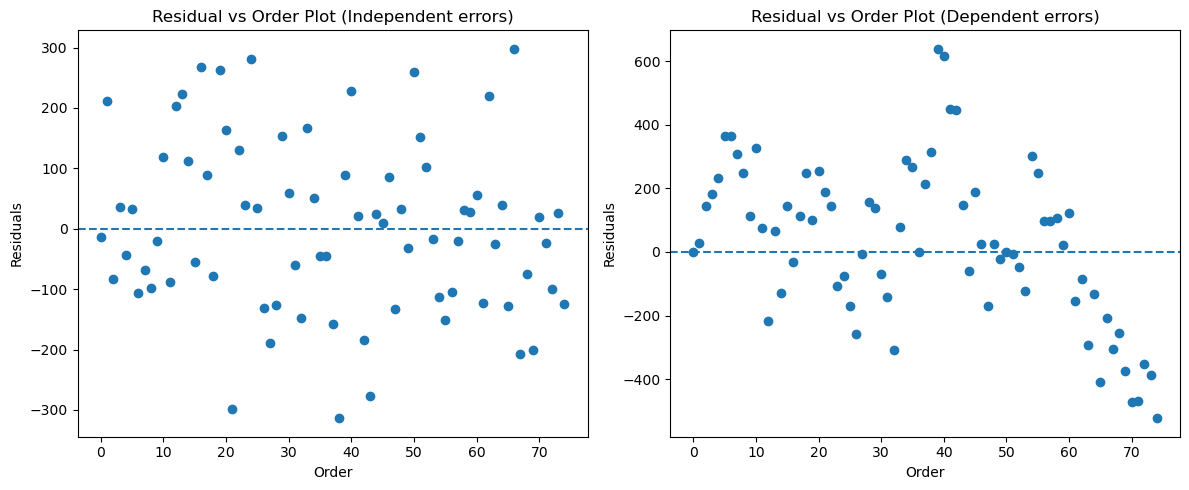

In [84]:
# Generate data
np.random.seed(2148) 
n = 75
x1 = np.random.randint(100,300,n) # kilometers
x2 = np.random.randint(2,20,n) # car ages in years
X = np.column_stack([np.ones(n),x1,x2]) # Regression matrix
theta = np.array([12, 4.5, 6]) # parameter vector
true_price = X @ theta
error_ind = np.random.normal(0,150,n) # independent errors
price = true_price + error_ind # distorted relationship using independent errors
res_ind = price - true_price # residuals of independent errors

# Dependent errors by creating autocorrelated errors (AR(1))
rho = 0.8
errors_dep = np.zeros(n)

for i in range(1, n):
    errors_dep[i] = rho * errors_dep[i-1] + np.random.normal(0, 150) # next error depends on previous one with formula error_i = p*error_i-1 + noise


price_ = true_price + errors_dep # distorted relationship using dependent errors
res_dep = price_ - true_price # residuals of dependent errors

#help(px.scatter_3d)

# Create grid
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 20),
    np.linspace(x2.min(), x2.max(), 20)
)

grid_y = 12 + 4.5*grid_x1 + 6*grid_x2  # true linear model

# Independent errors
fig1 = px.scatter_3d(
    x=x1, y=x2, z=price,
    title="Independent Errors",
    labels={'x':'Distance (km)', 'y':'Age', 'z':'Price'},
    color_discrete_sequence=['pink']  # all points 
)

# Add Regression plane
fig1.add_traces(
    go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=grid_y,
        opacity=0.4, # color intensity of plane
        showscale=False, # hides scalebar
        name="True Plane",
        showlegend=True  
    )
)


fig1.update_layout(width=700, height=500)
fig1.show()


# Dependent errors
fig2 = px.scatter_3d(
    x=x1, y=x2, z=price_,
    title="Dependent Errors (Autocorrelation)",
    labels={'x':'Distance (km)', 'y':'Age', 'z':'Price'},
    color_continuous_scale='Viridis'  # choose colormap
)

# Add Regression plane
fig2.add_traces(
    go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=grid_y,
        showscale=False, # hides scalebar
        opacity=0.4, # color intensity of plane
        name="True Plane",
        showlegend=True,
        colorscale='Blues' # change the plane color 
    )
)

fig2.update_layout(width=700, height=500)
fig2.show()


fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Independent errors
axes[0].scatter(range(n),res_ind)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residual vs Order Plot (Independent errors)")
axes[0].set_ylabel("Residuals")
axes[0].set_xlabel("Order")


# Dependent errors
axes[1].scatter(range(n),res_dep)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residual vs Order Plot (Dependent errors)")
axes[1].set_ylabel("Residuals")
axes[1].set_xlabel("Order")

plt.tight_layout()
plt.show()


### Homoskedasticity


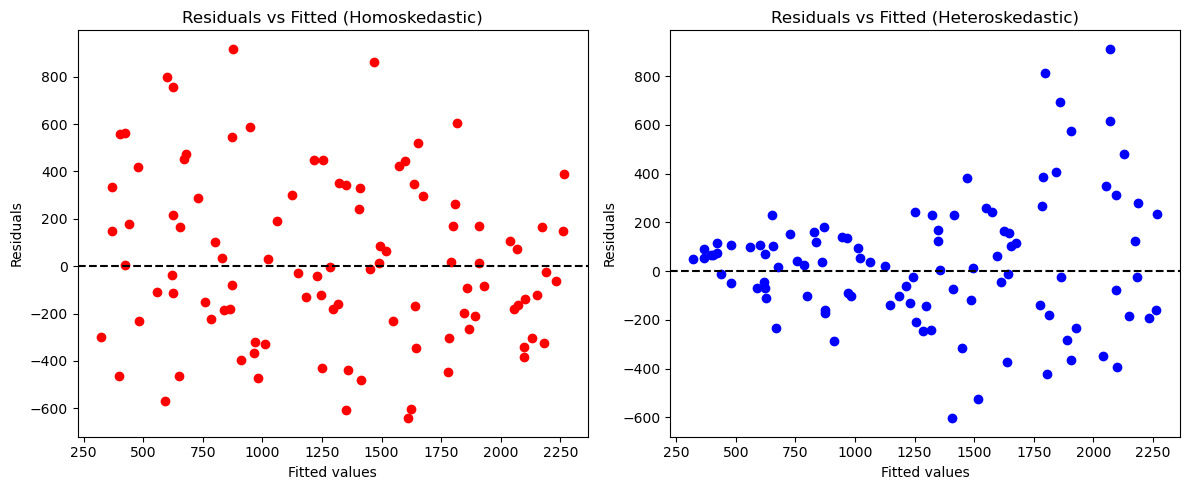

In [85]:
# Generate data
np.random.seed(2231)
n = 100

# Features
x1 = np.random.uniform(1, 10, n)
x2 = np.random.uniform(25, 200, n)
X = np.column_stack([np.ones(n), x1, x2])

# True coefficients
theta = np.random.randint(0, 20, 3)

# True target
true_y = X @ theta

# Homoskedastic errors
error_homo = np.random.normal(0, 300, n)
y_homo = true_y + error_homo

# Heteroskedastic errors (variance changes)
error_hetero = np.random.normal(0, 0.5 + 2*(x1+x2), n)
y_hetero = true_y + error_hetero

# Residuals using true coefficients
res_homo = y_homo - true_y
res_hetero = y_hetero - (X @ theta) # true_y = X @ theta


# Create grid for surfaces
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)
grid_X = np.column_stack([np.ones(grid_x1.size), grid_x1.ravel(), grid_x2.ravel()])
surface_true = (grid_X @ theta).reshape(grid_x1.shape)


# 3D scatterplots with regression plane
# Homoskedastic
fig1 = px.scatter_3d(
    x=x1, y=x2, z=y_homo,
    title="Homoskedastic Errors",
    labels={'x':'x1', 'y':'x2', 'z':'y'},
    color_discrete_sequence=['red']
)
fig1.add_traces(go.Surface(
    x=grid_x1, y=grid_x2, z=surface_true,
    opacity=0.5, showscale=False,
    name="True Plane", showlegend=True
))
fig1.update_layout(width=700, height=500)
fig1.show()

# Heteroskedastic
fig2 = px.scatter_3d(
    x=x1, y=x2, z=y_hetero,
    title="Heteroskedastic Errors",
    labels={'x':'x1', 'y':'x2', 'z':'y'},
    color_discrete_sequence=['blue']
)
fig2.add_traces(go.Surface(
    x=grid_x1, y=grid_x2, z=surface_true,
    opacity=0.5, showscale=False,
    name="True Plane", showlegend=True
))
fig2.update_layout(width=700, height=500)
fig2.show()


# Residuals vs fitted values
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(true_y, res_homo, color='red')
axes[0].axhline(0, linestyle='--', color='black')
axes[0].set_title("Residuals vs Fitted (Homoskedastic)")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

axes[1].scatter(true_y, res_hetero, color='blue')
axes[1].axhline(0, linestyle='--', color='black')
axes[1].set_title("Residuals vs Fitted (Heteroskedastic)")
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

### Zero Mean errors


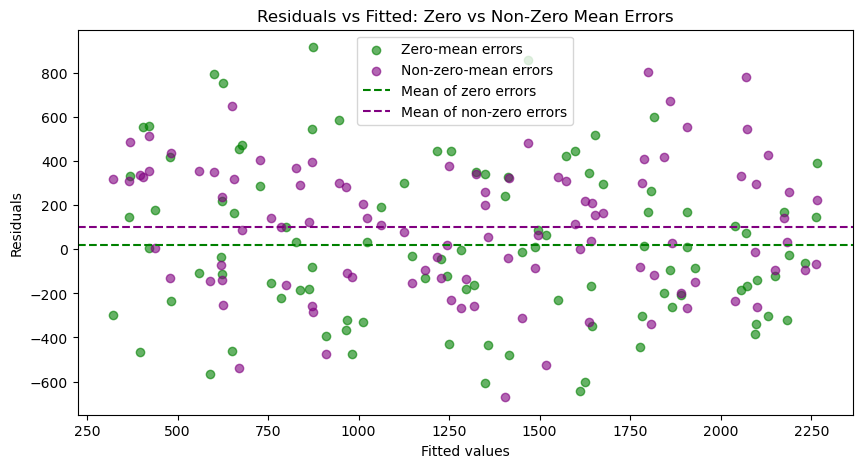

In [86]:
# Generate data
np.random.seed(2231)
n = 100

# Features
x1 = np.random.uniform(1, 10, n)
x2 = np.random.uniform(25, 200, n)
X = np.column_stack([np.ones(n), x1, x2])

# True coefficients
theta = np.random.randint(0, 20, 3)

# True target
true_y = X @ theta

# Errors
error_zero_mean = np.random.normal(0, 300, n)
error_nonzero_mean = np.random.normal(50, 300, n)  # mean = 50

# Observed values
y_zero = true_y + error_zero_mean
y_nonzero = true_y + error_nonzero_mean

# Residuals using true coefficients
res_zero = y_zero - true_y
res_nonzero = y_nonzero - true_y


# Create grid for surfaces
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)
grid_X = np.column_stack([np.ones(grid_x1.size), grid_x1.ravel(), grid_x2.ravel()])
surface_true = (grid_X @ theta).reshape(grid_x1.shape)


# 3D scatterplots with regression plane
# Zero-mean errors
fig1 = px.scatter_3d(
    x=x1, y=x2, z=y_zero,
    title="Homoskedastic Errors: Zero Mean",
    labels={'x':'x1', 'y':'x2', 'z':'y'},
    color_discrete_sequence=['green']
)
fig1.add_traces(go.Surface(
    x=grid_x1, y=grid_x2, z=surface_true,
    opacity=0.5, showscale=False,
    name="True Plane", showlegend=True
))
fig1.update_layout(width=700, height=500)
fig1.show()

# Non-zero mean errors
fig2 = px.scatter_3d(
    x=x1, y=x2, z=y_nonzero,
    title="Homoskedastic Errors: Non-Zero Mean",
    labels={'x':'x1', 'y':'x2', 'z':'y'},
    color_discrete_sequence=['purple']
)
fig2.add_traces(go.Surface(
    x=grid_x1, y=grid_x2, z=surface_true,
    opacity=0.5, showscale=False,
    name="True Plane", showlegend=True
))
fig2.update_layout(width=700, height=500)
fig2.show()

# Residuals vs fitted values
fitted = true_y  # linear model, fitted = true_y = X @ theta

plt.figure(figsize=(10,5))
plt.scatter(fitted, res_zero, color='green', alpha=0.6, label='Zero-mean errors')
plt.scatter(fitted, res_nonzero, color='purple', alpha=0.6, label='Non-zero-mean errors')

# Horizontal lines
plt.axhline(np.mean(error_zero_mean), linestyle='--', color='green', label='Mean of zero errors')
plt.axhline(np.mean(error_nonzero_mean), linestyle='--', color='purple', label='Mean of non-zero errors')

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted: Zero vs Non-Zero Mean Errors")
plt.legend()
plt.show()

### Normaility of errors

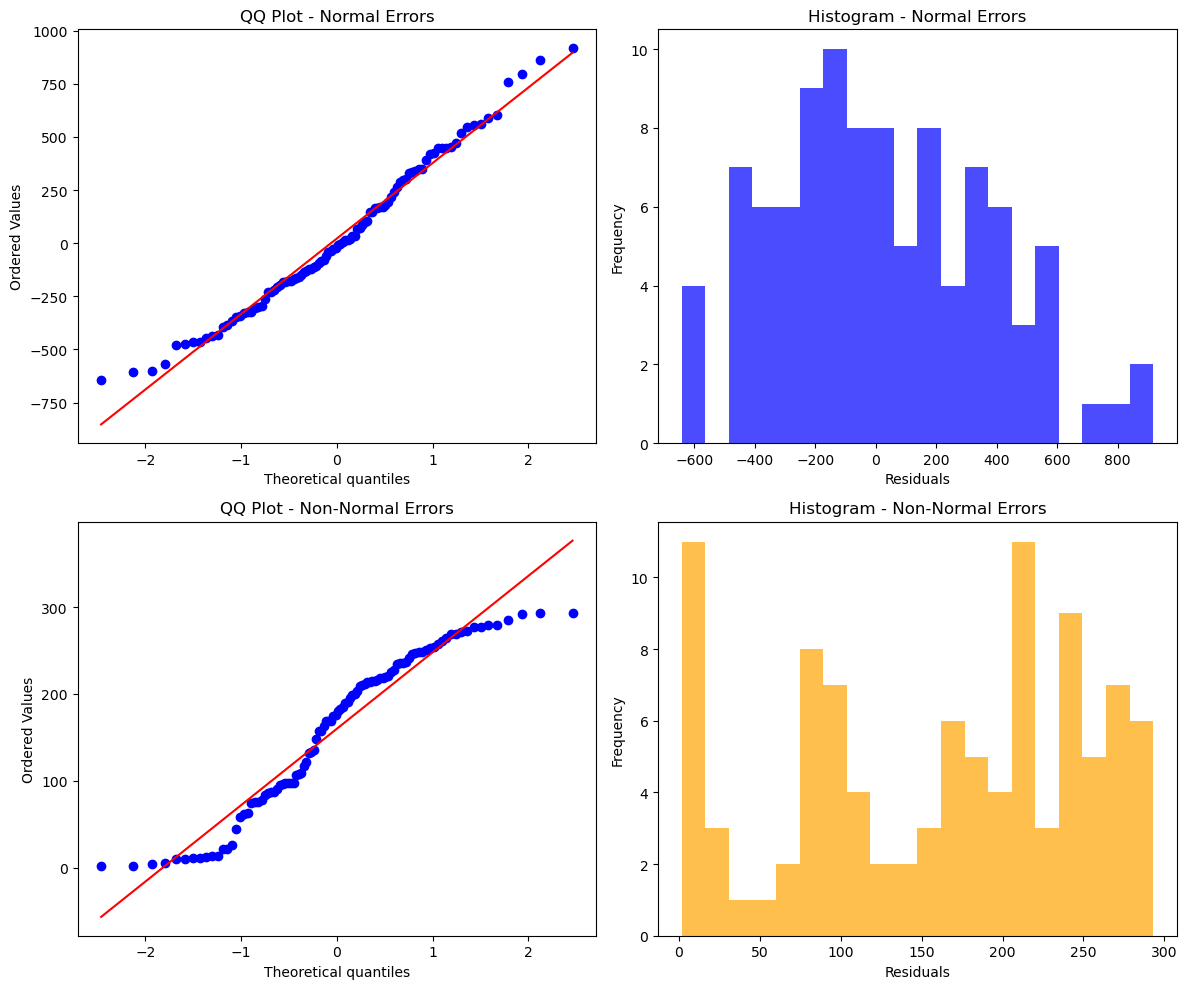

In [87]:
# Generate data
np.random.seed(2231)
n = 100

# Features
x1 = np.random.uniform(1, 10, n)
x2 = np.random.uniform(25, 200, n)
X = np.column_stack([np.ones(n), x1, x2])

# True coefficients
theta = np.random.randint(0, 20, 3)

# True target
true_y = X @ theta

# Errors
error_normal = np.random.normal(0, 300, n) # normal errors
error_non_normal = np.random.uniform(0,300,n) # uniform errors

# Observed values
y_normal = true_y + error_normal
y_non_normal = true_y + error_non_normal

# Residuals using true coefficients
res_normal = y_normal - true_y
res_non_normal = y_non_normal - true_y


# Create grid for surfaces
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)
grid_X = np.column_stack([np.ones(grid_x1.size), grid_x1.ravel(), grid_x2.ravel()])
surface_true = (grid_X @ theta).reshape(grid_x1.shape)


# 3D scatterplots with regression plane
# Normal errors
fig1 = px.scatter_3d(
    x=x1, y=x2, z=y_normal,
    title="Normal Errors",
    labels={'x':'x1', 'y':'x2', 'z':'y'},
    color_discrete_sequence=["blue"]
)
fig1.add_traces(go.Surface(
    x=grid_x1, y=grid_x2, z=surface_true,
    opacity=0.5, showscale=False,
    name="True Plane", showlegend=True
))
fig1.update_layout(width=700, height=500)
fig1.show()

# Non-normal errors
fig2 = px.scatter_3d(
    x=x1, y=x2, z=y_non_normal,
    title="Non-Normal Errors (Heavy Tails)",
    labels={'x':'x1', 'y':'x2', 'z':'y'},
    color_discrete_sequence=['orange']
)
fig2.add_traces(go.Surface(
    x=grid_x1, y=grid_x2, z=surface_true,
    opacity=0.5, showscale=False,
    name="True Plane", showlegend=True
))
fig2.update_layout(width=700, height=500)
fig2.show()


# QQ plots and histograms
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# QQ plot: normal errors
stats.probplot(res_normal, dist="norm", plot=axes[0,0])
axes[0,0].set_title("QQ Plot - Normal Errors")

# Histogram: normal errors
axes[0,1].hist(res_normal, bins=20, color='blue', alpha=0.7)
axes[0,1].set_title("Histogram - Normal Errors")
axes[0,1].set_xlabel("Residuals")
axes[0,1].set_ylabel("Frequency")

# QQ plot: non-normal errors
stats.probplot(res_non_normal, dist="norm", plot=axes[1,0])
axes[1,0].set_title("QQ Plot - Non-Normal Errors")

# Histogram: non-normal errors
axes[1,1].hist(res_non_normal, bins=20, color='orange', alpha=0.7)
axes[1,1].set_title("Histogram - Non-Normal Errors")
axes[1,1].set_xlabel("Residuals")
axes[1,1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### No Multicollinearity

In [ ]:
np.random.seed(1357)  # set seed
n = 100  # number of observations


# 1. UNCORRELATED FEATURES (full rank case)
print("----- UNCORRELATED FEATURES (FULL RANK) ------")

x1 = np.random.uniform(1, 10, n)
x2 = np.random.uniform(25, 200, n)

X_uncorr = np.column_stack([np.ones(n), x1, x2])

beta_true = np.array([5, 2, 1])
y_uncorr = X_uncorr @ beta_true + np.random.normal(0, 10, n)

# Check rank
rank_uncorr = np.linalg.matrix_rank(X_uncorr)
print("Rank of X_uncorr:", rank_uncorr)
print("Number of columns:", X_uncorr.shape[1])

print("\nSince rank = number of columns -> FULL RANK")
print("=> No null space exists (only the zero vector)")
print("=> Unique solution for beta")
print("=> Changing beta will change predictions\n")

# Create different beta vectors (arbitrary perturbations)
betas_uncorr = [
    beta_true + np.array([0, 50, -50]),
    beta_true + np.array([0, -30, 30]),
    beta_true + np.array([10, 0, 0]),
    beta_true + np.array([-20, 10, -10])
]

# Compare predictions
print("Comparing predictions for different beta values:\n")
for i, b in enumerate(betas_uncorr):
    diff = np.max(np.abs(X_uncorr @ b - X_uncorr @ beta_true))
    print(f"Max prediction difference for beta {i}: {diff:.4f}")

print("\n=> Different beta values lead to different predictions\n\n")



# 2. CORRELATED FEATURES (RANK DEFICIENT CASE)
print("------ CORRELATED FEATURES (MULTICOLLINEARITY) ------")

x1_c = np.random.uniform(1, 10, n)
x2_c = 2 * x1_c  # perfect linear dependence

X_corr = np.column_stack([np.ones(n), x1_c, x2_c])
y_corr = X_corr @ beta_true + np.random.normal(0, 10, n)

# Check rank
rank_corr = np.linalg.matrix_rank(X_corr)
print("Rank of X_corr:", rank_corr)
print("Number of columns:", X_corr.shape[1])

print("\nSince rank < number of columns -> RANK DEFICIENT")
print("=> Null space exists (non-zero vectors)")
print("=> NO unique solution for beta")
print("=> Infinitely many beta give the same predictions\n")

# Find null space vector using SVD
U, S, Vt = np.linalg.svd(X_corr)
null_vector = Vt[-1] # Correlated features => X_corr @ (betas + t*v) with v from null_space(X_corr) yield same predictions

print("Checking null space property:")
print("X_corr @ null_vector =", np.round(np.sum(X_corr @ null_vector),2))
print("=> This is approximately zero -> valid null space direction\n")

# Generate alternative beta vectors along null space
betas_corr = [beta_true + t * null_vector for t in [-50, -20, 0, 20, 50]]

# Compare predictions
print("Comparing predictions for different beta values along null space:\n")
for i, b in enumerate(betas_corr):
    diff = np.max(np.abs(X_corr @ b - X_corr @ beta_true))
    print(f"Max prediction difference for beta {i}: {diff:.8f}")

print("\n=> Different beta values lead to IDENTICAL predictions")
print("=> This happens because we move along the null space of X\n")

----- UNCORRELATED FEATURES (FULL RANK) ------
Rank of X_uncorr: 3
Number of columns: 3

Since rank = number of columns -> FULL RANK
=> No null space exists (only the zero vector)
=> Unique solution for beta
=> Changing beta will change predictions

Comparing predictions for different beta values:

Max prediction difference for beta 0: 9782.3199
Max prediction difference for beta 1: 5869.3920
Max prediction difference for beta 2: 10.0000
Max prediction difference for beta 3: 1976.4640

=> Different beta values lead to different predictions


------ CORRELATED FEATURES (MULTICOLLINEARITY) ------
Rank of X_corr: 2
Number of columns: 3

Since rank < number of columns -> RANK DEFICIENT
=> Null space exists (non-zero vectors)
=> NO unique solution for beta
=> Infinitely many beta give the same predictions

Checking null space property:
X_corr @ null_vector = 0.0
=> This is approximately zero -> valid null space direction

Comparing predictions for different beta values along null space:

Ma

### VIF (Variance Inflation Factor)

$$
\mathrm{VIF}_j = \frac{1}{1-\mathrm{R}_j^2}
$$

$$
\mathrm{R}_j^2 = \frac{\text{SSR}_j}{\text{SST}_j} = 1 - \frac{\text{SSE}_j}{\text{SST}_j}
$$

$$
\underbrace{\text{SST}_j = \sum_{i=1}^n (x_{ji} - \bar{x}_j)^2}_{\text{total variation of }x_j}
\hspace{1 mm} \mid \hspace{1 mm} 
\underbrace{\text{SSR}_j = \sum_{i=1}^n (\hat{x}_{ji} - \bar{x}_j)^2}_{\text{variation explained by regressing } x_j​ \text{ on other predictors}}
\hspace{1 mm} \mid \hspace{1 mm} 
\underbrace{\text{SSE}_j = \sum_{i=1}^n (x_{ji} - \hat{x}_{ji})^2}_{\text{residual variation}}
$$

- $i=1,...,n$
- $\mathrm{VIF}_j$ < 5 means predictor $x_j$ is weakly correlated to the other predictors
- $\mathrm{VIF}_j \approx$ 5 means predictor $x_j$ is moderately correlated to the other predictors
- $\mathrm{VIF}_j$ > 5 means predictor $x_j$ is strongly correlated to the other predictors
- $\mathrm{VIF}_j \rightarrow \infty$ means predictor $x_j$ is perfectly correlated to the other predictors (because $\mathrm{R}_j^2=1$)

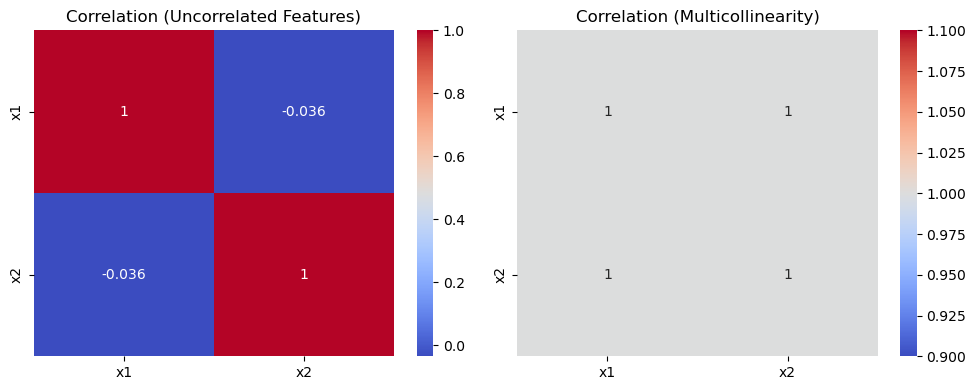


----- VIF: UNCORRELATED FEATURES -----
  Feature       VIF
0      x1  2.988253
1      x2  2.988253

----- VIF: CORRELATED FEATURES -----
  Feature  VIF
0      x1  inf
1      x2  inf


c:\Users\iyke\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



In [ ]:
# Correlation Heatmaps

# Uncorrelated data (exclude intercept!)
df_uncorr = pd.DataFrame({
    "x1": x1,
    "x2": x2
})

# Correlated data
df_corr = pd.DataFrame({
    "x1": x1_c,
    "x2": x2_c
})

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(df_uncorr.corr(), annot=True, cmap="coolwarm", ax=axes[0])
axes[0].set_title("Correlation (Uncorrelated Features)")

sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation (Multicollinearity)")

plt.tight_layout()
plt.show()



# VIF (Variance Inflation Factor)
print("\n----- VIF: UNCORRELATED FEATURES -----")
X_uncorr_df = pd.DataFrame({
    "x1": x1,
    "x2": x2
})

vif_uncorr = pd.DataFrame()
vif_uncorr["Feature"] = X_uncorr_df.columns
vif_uncorr["VIF"] = [
    variance_inflation_factor(X_uncorr_df.values, i)
    for i in range(X_uncorr_df.shape[1])
]

print(vif_uncorr)


print("\n----- VIF: CORRELATED FEATURES -----")
X_corr_df = pd.DataFrame({
    "x1": x1_c,
    "x2": x2_c
})

vif_corr = pd.DataFrame()
vif_corr["Feature"] = X_corr_df.columns
vif_corr["VIF"] = [
    variance_inflation_factor(X_corr_df.values, i)
    for i in range(X_corr_df.shape[1])
]

print(vif_corr)

<a class="anchor" id="min"></a>
## 3. Core Minimization problem (Ordinary Least Squares)

### Model

In Multiple Linear Regression, the target variable $y$ is modeled as a linear combination of multiple features:

$$
y^{(i)} = \theta^\top x^{(i)} + \varepsilon^{(i)} = \theta_0 + \theta_1 x_1^{(i)} + \ldots + \theta_p x_p^{(i)} + \varepsilon^{(i)}, \hspace{1 mm} i=1,\ldots,n \\ \Leftrightarrow
\underbrace{\begin{pmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(n)} \end{pmatrix}}_{y} 
= \theta_0 \underbrace{\begin{pmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{pmatrix}}_{1_n} 
+ \theta_1 \underbrace{\begin{pmatrix} x_1^{(1)} \\ x_1^{(2)} \\ \vdots \\ x_1^{(n)} \end{pmatrix}}_{x_1}
+ \ldots 
+ \theta_p \underbrace{\begin{pmatrix} x_p^{(1)} \\ x_p^{(2)} \\ \vdots \\ x_p^{(n)} \end{pmatrix}}_{x_p}
+ \underbrace{\begin{pmatrix} \varepsilon^{(1)} \\ \varepsilon^{(2)} \\ \vdots \\ \varepsilon^{(n)} \end{pmatrix}}_{\varepsilon} 
\\ \Leftrightarrow
\begin{pmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(n)} \end{pmatrix}=
\underbrace{\begin{pmatrix}
1 & x_1^{(1)} & \ldots & x_p^{(1)} \\
1 & x_1^{(2)} & \ldots & x_p^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_1^{(n)} & \ldots & x_p^{(n)}
\end{pmatrix}}_{X} 
\underbrace{\begin{pmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_p
\end{pmatrix}}_{\theta} +
\begin{pmatrix} \varepsilon^{(1)} \\ \varepsilon^{(2)} \\ \vdots \\ \varepsilon^{(n)} \end{pmatrix}
\\ \Leftrightarrow
y = X \theta + \varepsilon
$$





Where
* $X \in \mathbb{R}^{n \times (p+1)}$ is Regression matrix
* $x_j^{(i)}$ is the $j$-th feature of observation $i$ $(j=1,\ldots,p)$
* $\theta_j$ is the corresponding parameter from the parameter vector $\theta \in \mathbb{R}^{p+1}$
* $\varepsilon^{(i)}$ is the error term capturing noise 
* $\color{yellow}\varepsilon^{(i)} \sim \mathcal{N}(0,\sigma^2)\color{white}$ for all $i=1,\ldots,n$ or more general $\varepsilon \sim \mathcal{N}(0,\sigma^2 \mathrm{I}_n)$

$$
\text{Two approaches to OLS}
$$

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

### Predictions

The predicted value for observation $i$ is:

$$
\hat{y}^{(i)} = \hat{\theta}^\top x^{(i)} 
= \hat{\theta}_0 + \hat{\theta}_1 x_1^{(i)} + \ldots + \hat{\theta}_p x_p^{(i)}
$$

where $\hat{\theta}=(\hat{\theta}_0, \hat{\theta}_1, \ldots, \hat{\theta}_p)^\top \in \mathbb{R}^{p+1}$ are the estimated parameters 

---

### Residuals

The residuals are the differences between the observed and predicted values

$$
\begin{align*}
\varepsilon^{(i)} 
&= y^{(i)}-\hat{y}^{(i)} \\
&= y^{(i)}-\hat{\theta}^\top x^{(i)} \\
&= y^{(i)}-(\hat{\theta}_0 + \hat{\theta}_1 x_1^{(i)} + \ldots + \hat{\theta}_p x_p^{(i)}) \\
&= y^{(i)}-\hat{\theta}_0 - \hat{\theta}_1 x_1^{(i)} - \ldots - \hat{\theta}_p x_p^{(i)} \\
\end{align*}
$$

and the vector of residuals is

$$
\varepsilon = y - X \hat{\theta}
$$

---

### Ordinary Least Squares (OLS)

Multiple linear Regression estimates the parameters $\theta$ by minimizing the sum of squared residuals $\text{SSE}$ / L2-loss:

$$
\begin{align*}
\hat{\theta} \in \arg \min_{\theta \in \mathbb{R}^{p+1}} \mathcal{R}_{\text{emp}}(\theta)
&=\arg \min_{\theta \in \mathbb{R}^{p+1}} \sum_{i=1}^n (y^{(i)}-\theta^\top x^{(i)} )^2 \\
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} \lVert y - X\theta \rVert_2^2 \\
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} (y - X\theta)^\top (y - X\theta) \\
&= \frac{\partial}{\partial \theta}  (y - X\theta)^\top (y - X\theta) \\
&= \frac{\partial}{\partial \theta} \left(y^\top y - y^\top X\theta - (X\theta)^\top y + (X\theta)^\top X\theta \right) \\
&= \frac{\partial}{\partial \theta} \left(y^\top y - y^\top X\theta - \theta^\top X^\top y + \theta^\top X^\top X\theta \right) \\
&= \frac{\partial}{\partial \theta} \left(y^\top y  - 2\theta^\top X^\top y + \theta^\top X^\top X\theta \right) \\
&=  - 2X^\top y + 2 X^\top X\theta 
\end{align*}
$$

Setting the derivative to 0 yields

$$
\begin{align*}
- 2X^\top y + 2 X^\top X\theta &= 0 \\ \Leftrightarrow
2 X^\top X\theta &= 2X^\top y \\ \Leftrightarrow
2 \frac{1}{2} X^\top X\theta &= 2\frac{1}{2}  X^\top y \\ \Leftrightarrow
X^\top X\theta &= X^\top y \\ \Leftrightarrow
(X^\top X)^{-1}X^\top X\theta &= (X^\top X)^{-1}X^\top y \\ \Leftrightarrow
\theta &= (X^\top X)^{-1} X^\top y 
\end{align*}
$$

---

### OLS Solution

Solving the minimization yields the parameter estimates:

$$
\hat{\theta} = (X^\top X)^{-1} X^\top y 
$$

or explicitly:

$$
\begin{pmatrix}
\hat{\theta}_0 \\
\hat{\theta}_1 \\
\vdots \\
\hat{\theta}_p \\
\end{pmatrix} 
= (X^\top X)^{-1} X^\top
\begin{pmatrix}
y^{(0)} \\
y^{(1)} \\
\vdots \\
y^{(n)} \\
\end{pmatrix}  
$$

* Each $\hat{\theta}_j$ measures the effect of feature $x_j$ on the target, controlling for all other features
* $\hat{\theta}_0$ is the intercept (baseline prediction when all features are zero)

---




</div> 


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

### Distributions

$\varepsilon \sim \mathcal{N}(0,\sigma^2 \mathrm{I}_n) \Rightarrow y \mid X \sim \mathcal{N}(X\theta,\sigma^2 \mathrm{I}_n)$ 


</div>

</div> 

<a class="anchor" id="quality"></a>
## 4. Model Quality




In [ ]:
def compute_vif(X):
    """
    Compute VIF from scratch.
    X: numpy array (without intercept!)
    """
    n_features = X.shape[1]
    vif_values = []

    for j in range(n_features):
        # Target variable (x_j)
        y_j = X[:, j]
        
        # All other variables
        X_others = np.delete(X, j, axis=1)
        
        # Add intercept
        X_others = np.column_stack([np.ones(X_others.shape[0]), X_others])
        
        # OLS: beta = (X'X)^(-1) X'y
        beta_hat = np.linalg.inv(X_others.T @ X_others) @ X_others.T @ y_j
        
        # Predicted values
        y_hat = X_others @ beta_hat
        
        # Compute R^2
        ss_res = np.sum((y_j - y_hat)**2)
        ss_tot = np.sum((y_j - np.mean(y_j))**2)
        R2 = 1 - ss_res / ss_tot
        
        # Compute VIF
        vif = 1 / (1 - R2)
        vif_values.append(vif)
    
    return vif_values



<a class="anchor" id="stats"></a>
## 5. Statistical Inference




<a class="anchor" id="gd"></a>
## 6. (Batch) Gradient Descent

<a class="anchor" id="sgd"></a>
## 7. Stochastic Gradient Descent (SGD)